In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import DBSCAN

# Charger le dataset
# Remplacez 'mall_customer.csv' par le chemin vers votre fichier local.
data = pd.read_csv('Mall_Customers.csv')

In [3]:

# Affichage des 5 premières lignes pour vérifier le contenu du dataset
print(data.head())


   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [4]:

# Supposons que les colonnes pertinentes pour le clustering soient 'Age', 'Annual Income (k$)', 'Spending Score (1-100)'
features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
data = data[features]

# Normalisation des données avec MinMaxScaler
scaler = MinMaxScaler()
data_normalized = scaler.fit_transform(data)

In [6]:
# Définir une classe pour l'algorithme CLIQUE
class CLIQUE:
    def __init__(self, grid_size=0.1):
        self.grid_size = grid_size
        self.grid = {}
        self.dense_cells = {}

    def fit(self, X):
        self.grid = {}
        for idx, point in enumerate(X):
            cell = tuple((point // self.grid_size).astype(int))
            if cell not in self.grid:
                self.grid[cell] = []
            self.grid[cell].append(idx)

        # Identifier les cellules denses (seuil arbitraire de densité : 2% des points totaux)
        density_threshold = len(X) * 0.02
        self.dense_cells = {cell: points for cell, points in self.grid.items() if len(points) >= density_threshold}
        return self

    def predict(self, X):
        labels = -np.ones(len(X))  # Par défaut, tous les points sont considérés comme bruit (-1)
        cluster_id = 0

        for dense_cell in self.dense_cells:
            for idx in self.dense_cells[dense_cell]:
                if labels[idx] == -1:  # Si le point n'est pas encore assigné à un cluster
                    labels[idx] = cluster_id
            cluster_id += 1

        return labels


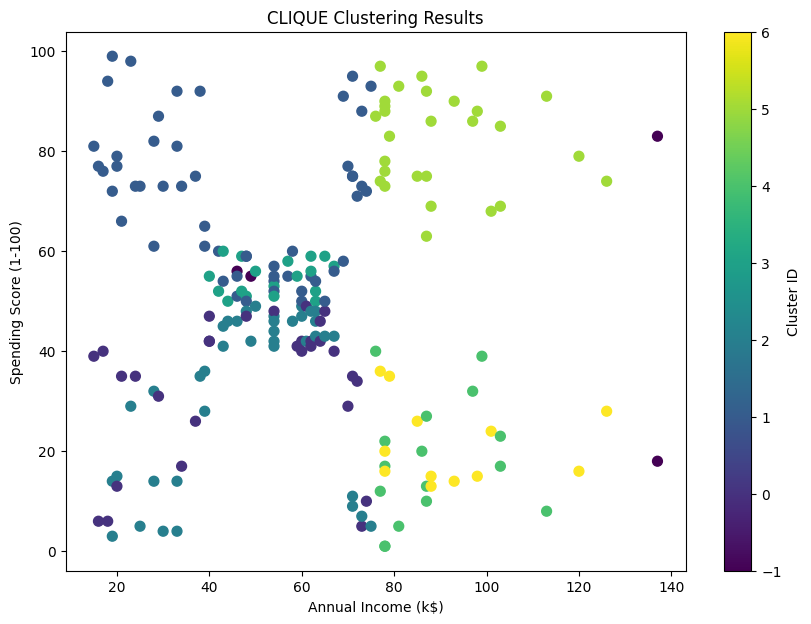

Cluster
-1.0     4
 0.0    30
 1.0    53
 2.0    39
 3.0    18
 4.0    16
 5.0    28
 6.0    12
dtype: int64


In [9]:
# Appliquer CLIQUE
clique = CLIQUE(grid_size=0.5)
clique.fit(data_normalized)
labels = clique.predict(data_normalized)

# Ajouter les étiquettes de cluster au dataset
data['Cluster'] = labels

# Visualisation des résultats
plt.figure(figsize=(10, 7))
plt.scatter(data['Annual Income (k$)'], data['Spending Score (1-100)'], c=labels, cmap='viridis', s=50)
plt.colorbar(label='Cluster ID')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('CLIQUE Clustering Results')
plt.show()

# Affichage des clusters
print(data.groupby('Cluster').size())
